In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
from sklearn.datasets import fetch_covtype

# print("Baixando os dados do Forest Cover Type... (Pode levar alguns segundos)")
# # O parâmetro as_frame=True já nos entrega os dados estruturados para o Pandas
# covtype = fetch_covtype(as_frame=True)

# # Criando o nosso DataFrame principal
# df_raw = covtype.frame

# print(f"Sucesso! Dataset carregado com {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")
# df_raw.head()

import pandas as pd

# URL direta do repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

# Como o arquivo original não vem com os nomes das colunas, nós definimos manualmente
# para manter o rigor e a organização do projeto.
columns = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

# Adicionando as colunas binárias de Wilderness Areas (4 colunas)
for i in range(1, 5):
    columns.append(f'Wilderness_Area_{i}')

# Adicionando as colunas binárias de Soil Types (40 colunas)
for i in range(1, 41):
    columns.append(f'Soil_Type_{i}')

# A última coluna é o nosso Target
columns.append('Cover_Type')

print("Buscando dados direto da UCI...")
df_raw = pd.read_csv(url, header=None, names=columns)
print(f"Sucesso! Dataset carregado com formato: {df_raw.shape}")
df_raw.head()

Buscando dados direto da UCI...
Sucesso! Dataset carregado com formato: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


O objetivo é prever o tipo de cobertura florestal utilizando apenas variáveis cartográficas (sem dados de sensoriamento remoto/imagens de satélite). O tipo real de cobertura florestal para uma determinada observação (uma célula de 30 x 30 metros) foi determinado a partir dos dados do Sistema de Informação de Recursos (RIS) da Região 2 do Serviço Florestal dos EUA (USFS). As variáveis independentes foram derivadas de dados originalmente obtidos do Serviço Geológico dos EUA (USGS) e do USFS. Os dados estão em sua forma bruta (não normalizados) e contêm colunas binárias (0 ou 1) para as variáveis independentes qualitativas (áreas selvagens e tipos de solo).

Esta área de estudo inclui quatro áreas selvagens localizadas na Floresta Nacional de Roosevelt, no norte do Colorado. Essas regiões representam florestas com o mínimo de perturbação causada pelo homem, de modo que os tipos de cobertura florestal existentes são mais o resultado de processos ecológicos do que de práticas de manejo florestal.


Contexto sobre as Quatro Áreas Selvagens:

- Neota (Área 2): Provavelmente possui o maior valor médio de elevação (altitude) entre as 4 áreas selvagens.

- Rawah (Área 1) e Comanche Peak (Área 3): Possuem um valor médio de elevação mais baixo que Neota.

- Cache la Poudre (Área 4): Possui o menor valor médio de elevação de todas.

Espécies de Árvores Dominantes por Área:

- Neota (Área 2): Tem como espécie principal o Abeto/Fruta-pinheiro (Spruce/Fir — Tipo 1).

- Rawah (Área 1) e Comanche Peak (Área 3): Provavelmente têm o Pinheiro-contorcido (Lodgepole Pine — Tipo 2) como espécie principal, seguido por Abeto/Fruta-pinheiro (Tipo 1) e Álamo (Aspen — Tipo 5).

- Cache la Poudre (Área 4): Tende a ter o Pinheiro-ponderosa (Ponderosa Pine — Tipo 3), Abeto-de-douglas (Douglas-fir — Tipo 6) e Choupo/Salgueiro (Cottonwood/Willow — Tipo 4).


Dinâmica do Dataset:

As áreas de Rawah e Comanche Peak tendem a ser mais típicas/representativas do dataset geral do que Neota ou Cache la Poudre, devido à sua variedade de espécies de árvores e amplitude de valores das variáveis preditivas (elevação, etc.). Já a área de Cache la Poudre provavelmente é a mais singular (um outlier de comportamento ou padrão único) em comparação com as outras, devido à sua faixa de elevação relativamente baixa e à sua composição específica de espécies.

Variáveis Numéricas (Contínuas): Elevação, Aspecto (direção da bússola para onde a encosta está virada), Inclinação (declividade do terreno), Distâncias horizontais e verticais até corpos d'água, Distância até rodovias, e Índices de sombreamento (Shadow Infill) em diferentes horários do dia (09h, 12h e 15h).

Variáveis Categóricas (Binárias / One-Hot Encoded): Áreas selvagens (Wilderness Areas — 4 colunas binárias) e Tipos de solo (Soil Types — 40 colunas binárias).

Target (Multiclasse): Cover_Type (valores inteiros de 1 a 7, representando diferentes tipos de árvores, como Spruce/Fir, Lodgepole Pine, Ponderosa Pine, etc.).

In [3]:
# --- Informações sobre shape ---
print(f'Shape: \n{df_raw.shape}\n')

# --- Informações sobre conlunas ---
print(f'Colunas: \n{df_raw.columns}\n')

Shape: 
(581012, 55)

Colunas: 
Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_1',
       'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4',
       'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4',
       'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8',
       'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12',
       'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16',
       'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20',
       'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24',
       'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28',
       'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32',
       'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Ty

In [4]:
# --- Agrupamento estatístico básico ---
estatisticas_elevacao = df_raw.groupby('Cover_Type')['Elevation'].agg(['mean', 'median', 'std', 'min', 'max'])
print(estatisticas_elevacao.round(2))

               mean  median     std   min   max
Cover_Type                                     
1           3128.64  3146.0  157.81  2466  3686
2           2920.94  2935.0  186.58  2142  3433
3           2394.51  2404.0  196.73  1859  2899
4           2223.94  2231.0  102.52  1988  2526
5           2787.42  2796.0   96.59  2482  3011
6           2419.18  2428.0  188.76  1863  2900
7           3361.93  3363.0  106.92  2868  3858


/tmp/ipykernel_14958/1594787837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Elevation', data=df_raw, palette='Set2')


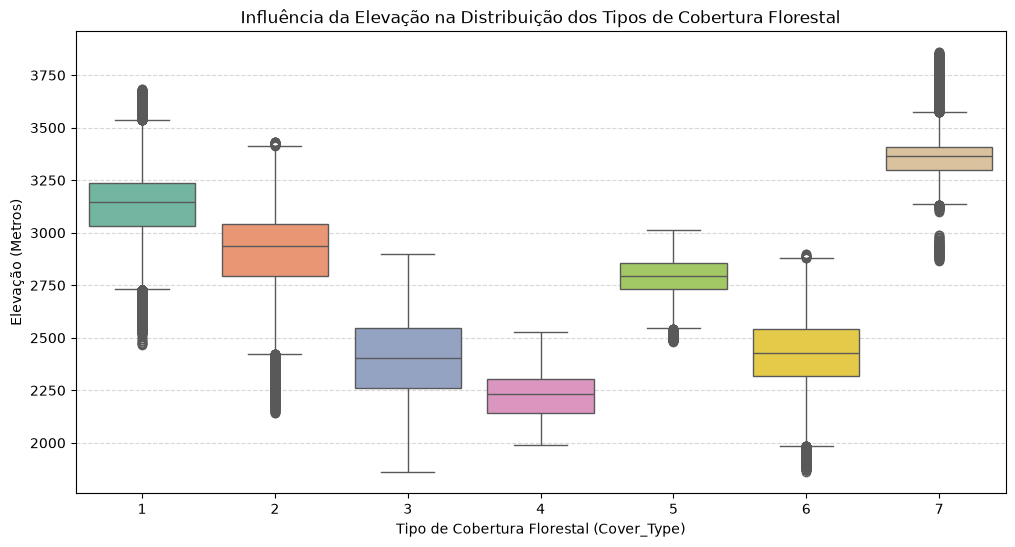

In [5]:
# --- Boxplot para validação visual dos quartis e distribuição ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cover_Type', y='Elevation', data=df_raw, palette='Set2')
plt.title('Influência da Elevação na Distribuição dos Tipos de Cobertura Florestal')
plt.xlabel('Tipo de Cobertura Florestal (Cover_Type)')
plt.ylabel('Elevação (Metros)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [6]:
print("\n--- ANÁLISE DE CORRELAÇÃO COBERTURA VS ÁREAS SELVAGENS ---")
# 3. Mapeando a frequência de cada Cover_Type nas 4 Wilderness Areas
wilderness_cols = [col for col in df_raw.columns if 'Wilderness_Area' in col]

# Vamos criar um resumo de contagem para cada área
for col in wilderness_cols:
    total_area = df_raw[df_raw[col] == 1].shape[0]
    print(f"\nDistribuição de Classes na {col} (Total de Amostras: {total_area}):")
    distribuicao = df_raw[df_raw[col] == 1]['Cover_Type'].value_counts().sort_index()
    for classe, qtd in distribuicao.items():
        pct = (qtd / total_area) * 100
        print(f"  - Classe {classe}: {qtd} amostras ({pct:.2f}%)")


--- ANÁLISE DE CORRELAÇÃO COBERTURA VS ÁREAS SELVAGENS ---

Distribuição de Classes na Wilderness_Area_1 (Total de Amostras: 260796):
  - Classe 1: 105717 amostras (40.54%)
  - Classe 2: 146197 amostras (56.06%)
  - Classe 5: 3781 amostras (1.45%)
  - Classe 7: 5101 amostras (1.96%)

Distribuição de Classes na Wilderness_Area_2 (Total de Amostras: 29884):
  - Classe 1: 18595 amostras (62.22%)
  - Classe 2: 8985 amostras (30.07%)
  - Classe 7: 2304 amostras (7.71%)

Distribuição de Classes na Wilderness_Area_3 (Total de Amostras: 253364):
  - Classe 1: 87528 amostras (34.55%)
  - Classe 2: 125093 amostras (49.37%)
  - Classe 3: 14300 amostras (5.64%)
  - Classe 5: 5712 amostras (2.25%)
  - Classe 6: 7626 amostras (3.01%)
  - Classe 7: 13105 amostras (5.17%)

Distribuição de Classes na Wilderness_Area_4 (Total de Amostras: 36968):
  - Classe 2: 3026 amostras (8.19%)
  - Classe 3: 21454 amostras (58.03%)
  - Classe 4: 2747 amostras (7.43%)
  - Classe 6: 9741 amostras (26.35%)


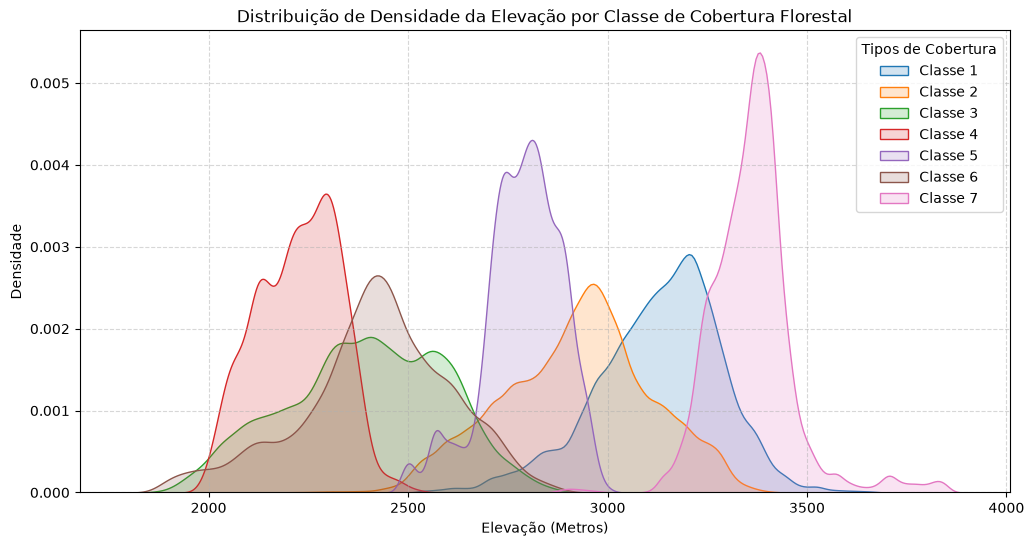

In [7]:
plt.figure(figsize=(12, 6))
# Filtrando e plotando a distribuição de elevação para cada uma das 7 classes
for i in range(1, 8):
    subset = df_raw[df_raw['Cover_Type'] == i]
    sns.kdeplot(subset['Elevation'], label=f'Classe {i}', fill=True, alpha=0.2)

plt.title('Distribuição de Densidade da Elevação por Classe de Cobertura Florestal')
plt.xlabel('Elevação (Metros)')
plt.ylabel('Densidade')
plt.legend(title='Tipos de Cobertura')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

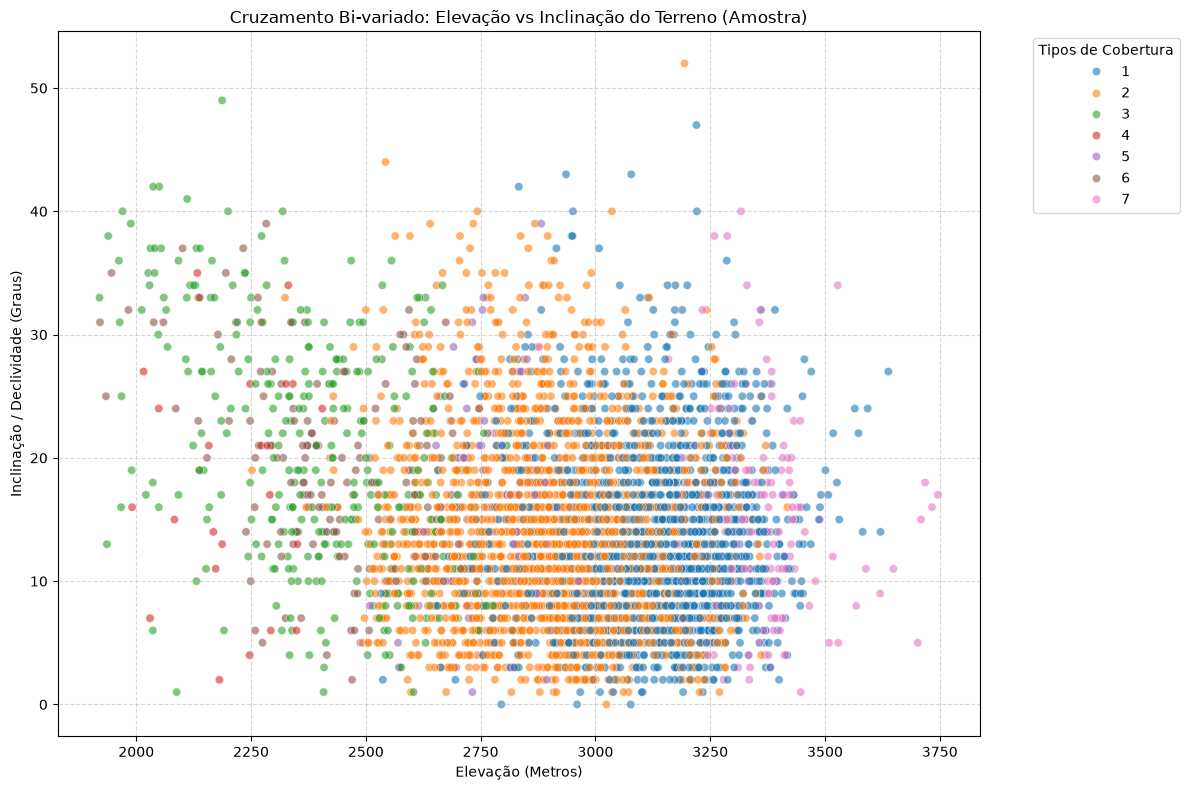

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantindo a amostragem de 5000 linhas
df_sample = df_raw.sample(n=5000, random_state=42)

plt.figure(figsize=(12, 8))

# Código corrigido (removido a duplicidade do argumento palette)
sns.scatterplot(
    x='Elevation',
    y='Slope',
    hue='Cover_Type',
    data=df_sample,
    alpha=0.6,
    palette=sns.color_palette("tab10", 7)
)

plt.title('Cruzamento Bi-variado: Elevação vs Inclinação do Terreno (Amostra)')
plt.xlabel('Elevação (Metros)')
plt.ylabel('Inclinação / Declividade (Graus)')
plt.legend(title='Tipos de Cobertura', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# 1. Filtrando o dataset apenas para as classes 3 e 6
df_3_6 = df_raw[df_raw['Cover_Type'].isin([3, 6])]

# 2. Isolando as colunas de Tipo de Solo
soil_cols = [col for col in df_raw.columns if 'Soil_Type' in col]

# 3. Agrupando por Cover_Type e somando a ocorrência de cada solo
solo_por_classe = df_3_6.groupby('Cover_Type')[soil_cols].sum()

# 4. Filtrando apenas os solos que aparecem de verdade (onde a soma é maior que zero)
solo_por_classe = solo_por_classe.loc[:, (solo_por_classe != 0).any(axis=0)]

print("---OCORRÊNCIA DE TIPOS DE SOLO PARA AS CLASSES 3 E 6 ---")
print(solo_por_classe.T)

---OCORRÊNCIA DE TIPOS DE SOLO PARA AS CLASSES 3 E 6 ---
Cover_Type        3     6
Soil_Type_1    2101   752
Soil_Type_2    4991  1303
Soil_Type_3    2411   203
Soil_Type_4    7501   631
Soil_Type_5     967   582
Soil_Type_6    3993  1350
Soil_Type_10  11532  8859
Soil_Type_11   1353   518
Soil_Type_13     41   614
Soil_Type_14    116   328
Soil_Type_15      0     3
Soil_Type_16    129   251
Soil_Type_17    506   709
Soil_Type_20      2   280
Soil_Type_23      0    29
Soil_Type_24      0   138
Soil_Type_31      0    63
Soil_Type_32    106   200
Soil_Type_33      5   539
Soil_Type_34      0    15


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 0. CRIAÇÃO DE FEATURE ADICIONAL
# ==========================================
# 1. ANTES DO SPLIT: Criando a feature matemática de Pitágoras
df_raw['Linear_Distance_To_Hydrology'] = np.sqrt(
    df_raw['Horizontal_Distance_To_Hydrology']**2 + 
    df_raw['Vertical_Distance_To_Hydrology']**2
)

# ==========================================
# 1. PREPARAÇÃO DOS DADOS & SPLIT INICIAL
# ==========================================
X = df_raw.drop(columns=['Cover_Type'])
y = df_raw['Cover_Type']

# Separando 20% do dataset completo para a "Urna de Validação Final"
# Usamos stratify=y para garantir a mesma proporção de classes em ambos os lados
X_development, X_validation_final, y_development, y_validation_final = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# 2. DEFINIÇÃO DO PRÉ-PROCESSAMENTO (PIPELINE)
# ==========================================
# Identificando as colunas numéricas contínuas que precisam de escala
num_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points', 'Linear_Distance_To_Hydrology'
]

# O ColumnTransformer permite aplicar transformações em colunas específicas
# remainder='passthrough' garante que as 44 colunas binárias não sejam alteradas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols)
    ],
    remainder='passthrough'
)

# Criando o Pipeline unificando o Pré-processamento e o Modelo
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ==========================================
# 3. VALIDAÇÃO CRUZADA E TUNAGEM (GRID SEARCH)
# ==========================================
# Definimos o espaço de hiperparâmetros para testar
# Nota: Para o Pipeline, usamos o prefixo 'classifier__' para apontar para o modelo
param_grid = {
    # Testamos uma profundidade maior e fixamos 100 árvores para dar estabilidade
    'classifier__n_estimators': [100],
    'classifier__max_depth': [10, 15, 20, 25], 
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 0.2],
}

# Configurando a estratégia de Validação Cruzada (5 Folds)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Iniciando a Validação Cruzada com Grid Search dentro do Pipeline...")
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# O fit aqui faz a mágica: ele roda o pré-processamento de forma isolada em cada fold!
grid_search.fit(X_development, y_development)

print(f"\nMelhores Hiperparâmetros Encontrados: {grid_search.best_params_}")
print(f"Melhor Acurácia na Validação Cruzada: {grid_search.best_score_:.4f}")

# ==========================================
# 4. VALIDAÇÃO FINAL (TESTE CEGO NA URNA)
# ==========================================
# O grid_search automaticamente guarda o melhor modelo treinado com o dataset de desenvolvimento inteiro
best_model = grid_search.best_estimator_

# Fazendo a predição na nossa validação final (dados que o modelo nunca viu)
y_final_pred = best_model.predict(X_validation_final)

print("\n==========================================")
print("       RELATÓRIO DE VALIDAÇÃO FINAL       ")
print("==========================================")
print(classification_report(y_validation_final, y_final_pred))

Iniciando a Validação Cruzada com Grid Search dentro do Pipeline...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
